In [482]:
!pip3 install nltk

# Question 1

In [483]:
import nltk
from nltk.tokenize import word_tokenize

In [484]:
nltk.download('gutenberg')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

nltk.corpus.gutenberg.fileids()


[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [485]:
paradise_lost = nltk.corpus.gutenberg.words("milton-paradise.txt")
paradise_lost


['[', 'Paradise', 'Lost', 'by', 'John', 'Milton', ...]

In [486]:
stopword = set(nltk.corpus.stopwords.words('english'))
stopword

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [487]:
text_sentences = nltk.corpus.gutenberg.sents("milton-paradise.txt")[:10]

for sentence in text_sentences: 
    
    filtered_list = [word for word in sentence if word.lower() not in stopword]
    print(filtered_list)



['[', 'Paradise', 'Lost', 'John', 'Milton', '1667', ']']
['Book']
['Man', "'", 'first', 'disobedience', ',', 'fruit', 'forbidden', 'tree', 'whose', 'mortal', 'taste', 'Brought', 'death', 'World', ',', 'woe', ',', 'loss', 'Eden', ',', 'till', 'one', 'greater', 'Man', 'Restore', 'us', ',', 'regain', 'blissful', 'seat', ',', 'Sing', ',', 'Heavenly', 'Muse', ',', ',', 'secret', 'top', 'Oreb', ',', 'Sinai', ',', 'didst', 'inspire', 'shepherd', 'first', 'taught', 'chosen', 'seed', 'beginning', 'heavens', 'earth', 'Rose', 'Chaos', ':', ',', 'Sion', 'hill', 'Delight', 'thee', ',', 'Siloa', "'", 'brook', 'flowed', 'Fast', 'oracle', 'God', ',', 'thence', 'Invoke', 'thy', 'aid', 'adventurous', 'song', ',', 'middle', 'flight', 'intends', 'soar', 'th', "'", 'Aonian', 'mount', ',', 'pursues', 'Things', 'unattempted', 'yet', 'prose', 'rhyme', '.']
['chiefly', 'thou', ',', 'Spirit', ',', 'dost', 'prefer', 'temples', 'th', "'", 'upright', 'heart', 'pure', ',', 'Instruct', ',', 'thou', 'know', "'", 'st'

In [488]:
# Stem or lemmatize the words and find counts

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()


def clean_words(paradise_lost, stopword):

    """
    Create a function that takes in a list of words and a list of words to remove,
    then return clean_words.

    So I take in words and removes stopwords, punctuations, and single letters.
    Then lower case all of those words and lemmatize them. 
    Finally return a clean_word list.
    """

    words_lemmatized = [lemmatizer.lemmatize(word.lower())
        for word in paradise_lost
        if word.isalpha()
        and word.lower() not in stopword
        and len(word) > 1]
    return words_lemmatized

# Words count
len(paradise_lost)



96825

The reason I chose lemmatize over stem is because although stem can help find root words and faster to process, the root word it return might not make sense, or is not a real english word. However, lemmatize helps finding a form of word thats related in the dictionary, so it consider the context of the word and help return it into a meaningful base form (lemma).  

In [489]:
# Select the top 20 words and create a bar chart.
from collections import Counter
cleaned_words = clean_words(paradise_lost, stopword)

word_counts = Counter(cleaned_words)
top_20 = word_counts.most_common(20)

print(top_20)


[('heaven', 436), ('thou', 432), ('thy', 414), ('thee', 358), ('thus', 318), ('god', 316), ('shall', 283), ('yet', 228), ('earth', 217), ('though', 217), ('u', 187), ('man', 176), ('first', 175), ('day', 157), ('high', 153), ('one', 142), ('son', 132), ('far', 129), ('death', 127), ('may', 126)]


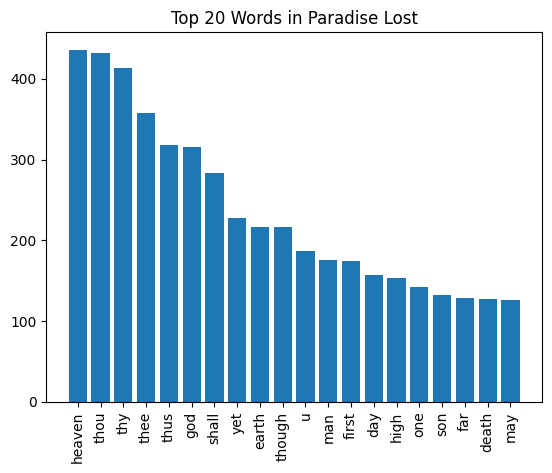

In [490]:
words = []
counts = []
for w in top_20:
    words.append(w[0])
    counts.append(w[1]) 

import matplotlib.pyplot as plt

plt.bar(words, counts)
plt.xticks(rotation = 90)
plt.title("Top 20 Words in Paradise Lost")
plt.show()

# Question 2

In [491]:
nltk.download('vader_lexicon')
nltk.download('subjectivity')
from nltk.classify import NaiveBayesClassifier
from nltk.corpus import subjectivity
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.sentiment.util import *



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package subjectivity to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package subjectivity is already up-to-date!


In [492]:
text_sentences = nltk.corpus.gutenberg.sents("milton-paradise.txt")[:10]
sentences_string = [''.join(sent) for sent in text_sentences]

print(sentences_string)


['[ParadiseLostbyJohnMilton1667]', 'BookI', "OfMan'sfirstdisobedience,andthefruitOfthatforbiddentreewhosemortaltasteBroughtdeathintotheWorld,andallourwoe,WithlossofEden,tillonegreaterManRestoreus,andregaintheblissfulseat,Sing,HeavenlyMuse,that,onthesecrettopOfOreb,orofSinai,didstinspireThatshepherdwhofirsttaughtthechosenseedInthebeginninghowtheheavensandearthRoseoutofChaos:or,ifSionhillDelighttheemore,andSiloa'sbrookthatflowedFastbytheoracleofGod,IthenceInvokethyaidtomyadventuroussong,ThatwithnomiddleflightintendstosoarAboveth'Aonianmount,whileitpursuesThingsunattemptedyetinproseorrhyme.", "Andchieflythou,OSpirit,thatdostpreferBeforealltemplesth'uprightheartandpure,Instructme,forthouknow'st;thoufromthefirstWastpresent,and,withmightywingsoutspread,Dove-likesat'stbroodingonthevastAbyss,Andmad'stitpregnant:whatinmeisdarkIllumine,whatislowraiseandsupport;That,totheheightofthisgreatargument,ImayassertEternalProvidence,AndjustifythewaysofGodtomen.", 'Sayfirst--forHeavenhidesnothingfromthyvie

In [493]:
analyzer = SentimentIntensityAnalyzer()

sentiments = []
for sent in sentences_string:
    sentiment = analyzer.polarity_scores(sent)
    sentiments.append((sent))

    compound = sentiment['compound']
    pos = sentiment['pos']
    neg = sentiment['neg']
    neu = sentiment['neu']   

    sentiments.append({
    "sentence": sent,
    "compound": compound,
    "positive": pos,
    "negative": neg,
    "neutral": neu})
    
sentiments


['[ParadiseLostbyJohnMilton1667]',
 {'sentence': '[ParadiseLostbyJohnMilton1667]',
  'compound': 0.0,
  'positive': 0.0,
  'negative': 0.0,
  'neutral': 1.0},
 'BookI',
 {'sentence': 'BookI',
  'compound': 0.0,
  'positive': 0.0,
  'negative': 0.0,
  'neutral': 1.0},
 "OfMan'sfirstdisobedience,andthefruitOfthatforbiddentreewhosemortaltasteBroughtdeathintotheWorld,andallourwoe,WithlossofEden,tillonegreaterManRestoreus,andregaintheblissfulseat,Sing,HeavenlyMuse,that,onthesecrettopOfOreb,orofSinai,didstinspireThatshepherdwhofirsttaughtthechosenseedInthebeginninghowtheheavensandearthRoseoutofChaos:or,ifSionhillDelighttheemore,andSiloa'sbrookthatflowedFastbytheoracleofGod,IthenceInvokethyaidtomyadventuroussong,ThatwithnomiddleflightintendstosoarAboveth'Aonianmount,whileitpursuesThingsunattemptedyetinproseorrhyme.",
 {'sentence': "OfMan'sfirstdisobedience,andthefruitOfthatforbiddentreewhosemortaltasteBroughtdeathintotheWorld,andallourwoe,WithlossofEden,tillonegreaterManRestoreus,andregainthe

# Question 3

Explain your findings from the previous question. Are the sentences and their sentiment analysis scores correct? Explain why or why not.





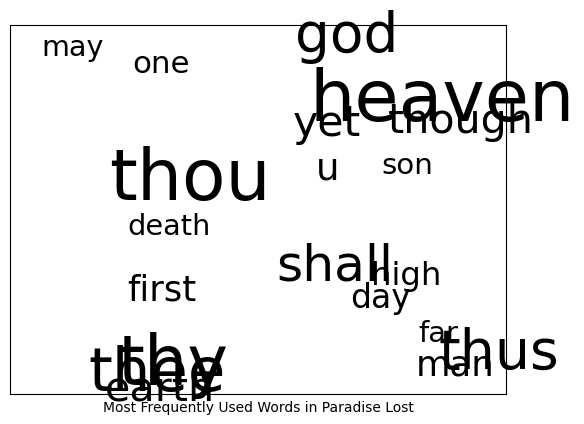

In [494]:
# Extra credit: create a word cloud for your results from question 1

wordcloud_data = [('heaven', 436), ('thou', 432), ('thy', 414), ('thee', 358), ('thus', 318), 
                  ('god', 316), ('shall', 283), ('yet', 228), ('earth', 217), ('though', 217), 
                  ('u', 187), ('man', 176), ('first', 175), ('day', 157), ('high', 153), ('one', 142), 
                  ('son', 132), ('far', 129), ('death', 127), ('may', 126)]

import matplotlib.pyplot as plt
def text_size(total:int) -> float:
    return 8 + total / 200 * 20
for word, popular_word in wordcloud_data:
    plt.text(random.uniform(0,100), random.uniform(0,100), word, 
             ha='center', va='center', size=text_size(popular_word))
plt.xlabel("Most Frequently Used Words in Paradise Lost")
plt.axis([0, 100, 0, 100])
plt.xticks([])
plt.yticks([])
plt.show()